## Problem 1

In [83]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('spambase/spambase.data', header=None)

# Split the dataset into features and target variable
X = df.iloc[:, :-1] 
y = df.iloc[:, -1]   

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train a logistic regression model
model = LogisticRegression(max_iter=2500)
model.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred = model.predict(X_test)
accuracy = model.score(X_test, y_test)
error = 1 - accuracy
cm = pd.DataFrame(confusion_matrix(y_test, y_pred), 
                   index=['Actual 0', 'Actual 1'], 
                   columns=['Predicted 0', 'Predicted 1'])
precision = cm.loc['Actual 1', 'Predicted 1'] / (cm.loc['Actual 0', 'Predicted 1'] + cm.loc['Actual 1', 'Predicted 1'])
recall = cm.loc['Actual 1', 'Predicted 1'] / (cm.loc['Actual 1', 'Predicted 0'] + cm.loc['Actual 1', 'Predicted 1'])
f1_score = 2 * (precision * recall) / (precision + recall)
print(cm)
print(f'Accuracy: {accuracy:.4f}')
print(f'Error: {error:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1_score:.4f} \n')

# print coefficients of the model
coefficients = pd.DataFrame(model.coef_[0], index=X.columns, columns=['Coefficient'])
print(coefficients)
print()

# Decision thresholds
thresholds = [0.25, 0.5, 0.75, 0.9]
for T in thresholds:
    y_pred_threshold = (model.predict_proba(X_test)[:, 1] >= T).astype(int)
    accuracy_threshold = (y_pred_threshold == y_test).mean()
    cm_threshold = pd.DataFrame(confusion_matrix(y_test, y_pred_threshold), 
                                       index=['Actual 0', 'Actual 1'], 
                                       columns=['Predicted 0', 'Predicted 1'])
    precision_threshold = cm_threshold.loc['Actual 1', 'Predicted 1'] / (cm_threshold.loc['Actual 0', 'Predicted 1'] + cm_threshold.loc['Actual 1', 'Predicted 1'])
    recall_threshold = cm_threshold.loc['Actual 1', 'Predicted 1'] / (cm_threshold.loc['Actual 1', 'Predicted 0'] + cm_threshold.loc['Actual 1', 'Predicted 1'])
    f1_score_threshold = 2 * (precision_threshold * recall_threshold) / (precision_threshold + recall_threshold)
    print(f'Threshold: {T}')
    print(f'Accuracy: {accuracy_threshold:.4f}')
    print(f'Precision: {precision_threshold:.4f}')
    print(f'Recall: {recall_threshold:.4f}')
    print(f'F1-Score: {f1_score_threshold:.4f}')
    print()

          Predicted 0  Predicted 1
Actual 0          651           25
Actual 1           55          420
Accuracy: 0.9305
Error: 0.0695
Precision: 0.9438
Recall: 0.8842
F1-Score: 0.9130 

    Coefficient
0     -0.243927
1     -0.129766
2      0.142222
3      0.751978
4      0.629927
5      0.654369
6      2.108550
7      0.499064
8      0.603091
9      0.078152
10    -0.372780
11    -0.094614
12     0.009225
13     0.089436
14     1.504005
15     1.008787
16     0.891106
17     0.085714
18     0.097550
19     0.905152
20     0.241260
21     0.235171
22     2.139296
23     0.370092
24    -1.815659
25    -0.759105
26    -4.195317
27     0.338244
28    -1.149879
29    -0.634186
30    -0.176859
31     0.113556
32    -1.194988
33     0.230556
34    -0.931059
35     0.979593
36    -0.065268
37    -0.518947
38    -0.814215
39    -0.062670
40    -1.344640
41    -1.537888
42    -0.692752
43    -1.727530
44    -0.664315
45    -1.342227
46    -0.719850
47    -1.785777
48    -1.009378
49    -0.194

## Problem 2

In [ ]:
# scale the features for gradient descent
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s = sc.transform(X_test)

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Cross-entropy loss function
def cross_entropy(X, y, w, b):
    h = np.clip(sigmoid(X @ w + b), 1e-12, 1 - 1e-12)
    return -np.mean(y * np.log(h) + (1 - y) * np.log(1 - h))

# Gradient Descent for Logistic Regression
def gd_logistic(X, y, lr, iters=100, checkpoints=[10, 50, 100]):
    w, b = np.zeros(X.shape[1]), 0.0
    m = len(y)
    losses = {}
    for i in range(1, iters + 1):
        h = sigmoid(X @ w + b)
        w -= (lr / m) * (X.T @ (h - y))
        b -= (lr / m) * np.sum(h - y)
        if i in checkpoints:
            losses[i] = cross_entropy(X, y, w, b)
    return w, b, losses

# Prediction function for GD model
def predict_gd(X, w, b):
    return (sigmoid(X @ w + b) >= 0.5).astype(int)

# Function to compute metrics from confusion matrix
def report_metrics(y_true, y_pred):
    _, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc = (y_pred == y_true).mean()
    prec = tp / (tp + fp) 
    rec = tp / (tp + fn) 
    f1 = 2 * prec * rec / (prec + rec)
    return acc, prec, rec, f1

lrs = [0.01, 0.1, 1.0]

gd_results = {}
loss_rows = []
for lr in lrs:
    w, b, losses = gd_logistic(X_train_s, y_train, lr)
    gd_results[lr] = (w, b)
    loss_rows.append({"LR": lr, "Iter 10": losses[10], "Iter 50": losses[50], "Iter 100": losses[100]})

print("\nCross-Entropy Loss at Iterations 10, 50, 100")
print(pd.DataFrame(loss_rows).to_string(index=False))

# Metrics at 100 Iterations
for label, Xs, ys in [("Training", X_train_s, y_train), ("Testing", X_test_s, y_test)]:
    rows = []
    for lr in lrs:
        w, b = gd_results[lr]
        yp = predict_gd(Xs, w, b)
        acc, prec, rec, f1 = report_metrics(ys, yp)
        rows.append({"LR": lr, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1})
    print(f"\nGD Metrics at 100 Iterations ({label} Set)")
    print(pd.DataFrame(rows).to_string(index=False))


Cross-Entropy Loss at Iterations 10, 50, 100
  LR  Iter 10  Iter 50  Iter 100
0.01 0.651167 0.541620  0.468734
0.10 0.465377 0.324124  0.289078
1.00 0.285267 0.243509  0.232082

GD Metrics at 100 Iterations (Training Set)
  LR  Accuracy  Precision   Recall       F1
0.01  0.897681   0.873389 0.860987 0.867143
0.10  0.907826   0.911290 0.844544 0.876649
1.00  0.920870   0.923628 0.867713 0.894798

GD Metrics at 100 Iterations (Testing Set)
  LR  Accuracy  Precision   Recall       F1
0.01  0.903562   0.900881 0.861053 0.880517
0.10  0.906169   0.923788 0.842105 0.881057
1.00  0.915725   0.931507 0.858947 0.893757


## Problem 3

In [68]:
# Find optimal k value for KNN
scoring = ['accuracy', 'precision', 'recall']
k_values = list(range(1, 25))
cv_results = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # using scaled features for KNN
    scores = cross_validate(knn, X_train_s, y_train, cv=5, scoring=scoring)

    acc = scores['test_accuracy'].mean()
    prec = scores['test_precision'].mean()
    rec = scores['test_recall'].mean()

    cv_results.append({
        "k": k,
        "Accuracy": acc,
        "Error": 1 - acc,
        "Precision": prec,
        "Recall": rec
    })

cv_df = pd.DataFrame(cv_results)
print(cv_df.to_string(index=False))

best_k = cv_df.loc[cv_df["Error"].idxmin(), "k"]
print(f"\nBest k = {int(best_k)} (lowest average CV error)\n")


 k  Accuracy    Error  Precision   Recall
 1  0.901449 0.098551   0.877659 0.866966
 2  0.893333 0.106667   0.926706 0.787744
 3  0.900870 0.099130   0.882465 0.859486
 4  0.902609 0.097391   0.921484 0.819140
 5  0.902609 0.097391   0.890578 0.854262
 6  0.899710 0.100290   0.917939 0.814651
 7  0.906667 0.093333   0.896286 0.859486
 8  0.901449 0.098551   0.917742 0.819887
 9  0.904928 0.095072   0.899431 0.850511
10  0.897101 0.102899   0.911622 0.813902
11  0.900580 0.099420   0.897707 0.840053
12  0.897681 0.102319   0.915146 0.811661
13  0.899420 0.100580   0.900827 0.832581
14  0.896522 0.103478   0.914115 0.809425
15  0.898841 0.101159   0.901660 0.830348
16  0.891014 0.108986   0.909000 0.799704
17  0.895072 0.104928   0.900088 0.821376
18  0.890435 0.109565   0.909282 0.797468
19  0.892464 0.107536   0.900093 0.813902
20  0.888986 0.111014   0.903639 0.799701
21  0.890725 0.109275   0.900240 0.808667
22  0.888696 0.111304   0.906362 0.795956
23  0.890145 0.109855   0.900173 0

In [84]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2500),
    "KNN": KNeighborsClassifier(n_neighbors=int(best_k)),
    "LDA" : LinearDiscriminantAnalysis()
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = model.score(X_test, y_test)
    error = 1 - acc
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()
    prec = TP / (TP + FP) 
    rec = TP / (TP + FN)
    print(f"{name} - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, Error: {error:.4f}")


Logistic Regression - Accuracy: 0.9305, Precision: 0.9438, Recall: 0.8842, Error: 0.0695
KNN - Accuracy: 0.7654, Precision: 0.7223, Recall: 0.7011, Error: 0.2346
LDA - Accuracy: 0.8853, Precision: 0.9298, Recall: 0.7811, Error: 0.1147


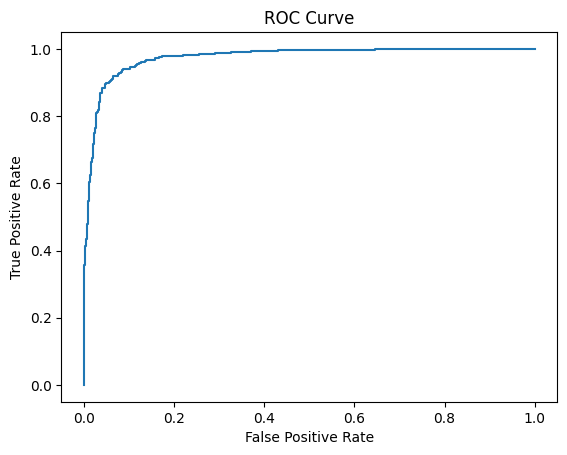

AUC Score: 0.9747


In [85]:
lr = models["Logistic Regression"]
lr.fit(X_train_s, y_train)

def plot_roc_curve(true_y, y_prob):
    fpr, tpr, _ = roc_curve(true_y, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate') 
    plt.title('ROC Curve')
    plt.show()

y_prob = lr.predict_proba(X_test_s)[:, 1]
plot_roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc_score:.4f}")

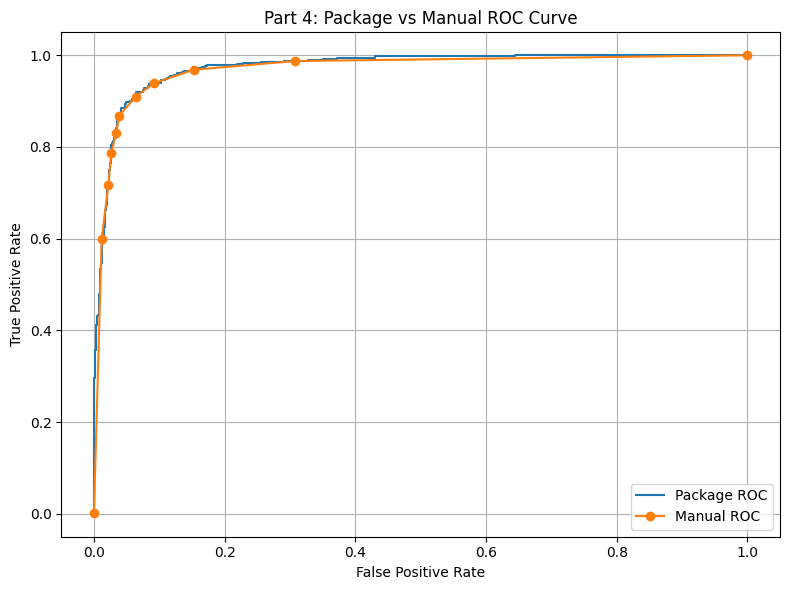

In [ ]:
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
fpr_manual, tpr_manual = [], []
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Compute manual FPR and TPR for each threshold
for T in thresholds:
    y_pred_t = (y_prob >= T).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    fpr_manual.append(fp / (fp + tn))
    tpr_manual.append(tp / (tp + fn))

# Plotting both ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Package ROC")
plt.plot(fpr_manual, tpr_manual, 'o-', label="Manual ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Part 4: Package vs Manual ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Problem 4

In [81]:
# Split the dataset into features and target variable and into numpy arrays for CV
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

def k_fold_cv(model, X, y, k):
    n = len(y)
    indices = np.arange(n)
    np.random.seed(42)
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)

    errors = []
    for i in range(k):
        # Test on fold i, train on the rest
        test_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        error = (y_pred != y_test).mean()
        errors.append(error)

    avg_error = np.mean(errors)
    return errors, avg_error


# Run CV for Logistic Regression and LDA, k=5 and k=10
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "LDA": LinearDiscriminantAnalysis()
}

k_values = [5, 10]
results = []

for name, model in models.items():
    for k in k_values:
        errors, avg_error = k_fold_cv(model, X, y, k)
        results.append({"Model": name, "k": k, "Avg Validation Error": avg_error})
        print(f"{name} (k={k}): Fold Errors = {[round(e, 4).item() for e in errors]}")

print("\nSummary:")
print(pd.DataFrame(results).to_string(index=False))

Logistic Regression (k=5): Fold Errors = [0.0771, 0.0707, 0.0761, 0.0685, 0.0685]
Logistic Regression (k=10): Fold Errors = [0.0759, 0.0739, 0.0565, 0.0761, 0.087, 0.0609, 0.0783, 0.0565, 0.0652, 0.0717]
LDA (k=5): Fold Errors = [0.1183, 0.1065, 0.1196, 0.1065, 0.112]
LDA (k=10): Fold Errors = [0.1171, 0.113, 0.1065, 0.1065, 0.1217, 0.1087, 0.1283, 0.0913, 0.1217, 0.113]

Summary:
              Model  k  Avg Validation Error
Logistic Regression  5              0.072157
Logistic Regression 10              0.070201
                LDA  5              0.112583
                LDA 10              0.112801
